**Ruiqi Liu**  
**CS6220**  
**Assignment 5**  
**2/14/2025**  

---



# Part 1: K-Means Clustering

# 1(a) Elbow Method
**Objective:**  
Utilize the elbow method to determine the optimal number of clusters for K-Means clustering by plotting the within-cluster sum of squares (WCSS) for different numbers of clusters.

**Steps:**
1. Load the Banknote Authentication dataset.
2. Apply K-Means clustering with a range of clusters (e.g., 1 to 9).
3. Plot the WCSS against the number of clusters to identify the "elbow" point.

**Output:**  
A plot of WCSS vs. Number of Clusters.


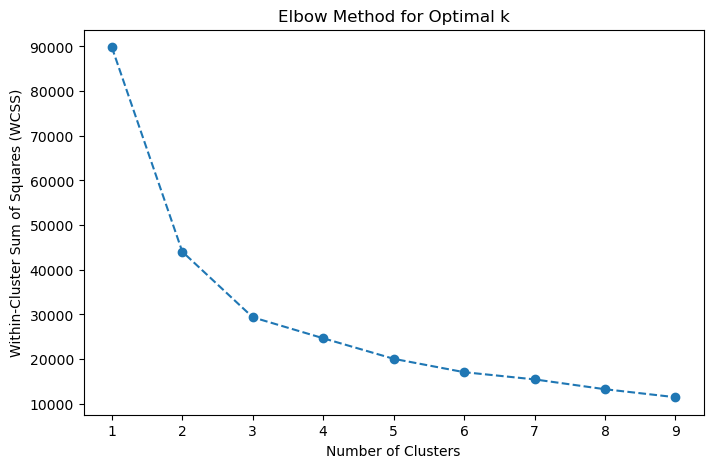

In [17]:
# 1(a) Elbow Method

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Load the dataset
data = pd.read_csv('data_banknote_authentication.txt', header=None, 
                   names=['variance', 'skewness', 'curtosis', 'entropy', 'class'])
X = data.drop('class', axis=1).values

# Test a range of clusters from 1 to 9
cluster_range = range(1, 10)
wcss = []  # within-cluster sum of squares

for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(cluster_range, wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.show()


# 1(b) Evaluation Metrics
**Objective:**  
Compute evaluation metrics for K-Means clustering on the original data for different numbers of clusters (2, 3, 4):
- **Adjusted Rand Index (ARI):** Measures similarity between the clustering and ground truth.
- **Silhouette Score:** Indicates the quality of clusters.
- **Percentage Accuracy:** The fraction of correctly assigned samples (only computed for k=2).

**Steps:**
1. Apply K-Means clustering for k = 2, 3, 4.
2. Compute ARI, Silhouette Score, and Percentage Accuracy.
3. Plot these metrics versus the number of clusters.

**Output:**  
Plots of ARI, Silhouette Score, and Percentage Accuracy vs. Number of Clusters.


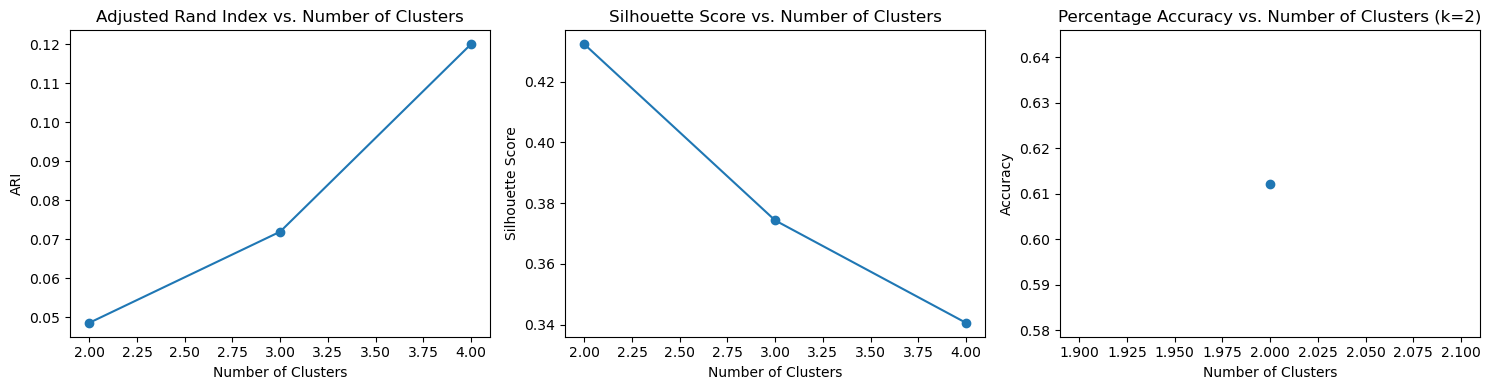

In [18]:
# 1(b) Evaluation Metrics

from sklearn.metrics import silhouette_score, adjusted_rand_score, confusion_matrix
from scipy.optimize import linear_sum_assignment
import numpy as np

def clustering_accuracy(y_true, y_pred):
    """Compute clustering accuracy using the Hungarian algorithm to optimally align cluster labels with true labels."""
    cm = confusion_matrix(y_true, y_pred)
    row_ind, col_ind = linear_sum_assignment(-cm)
    return cm[row_ind, col_ind].sum() / np.sum(cm)

ks = [2, 3, 4]
ari_scores = []
silhouette_scores = []
accuracy_scores = []

y_true = data['class'].values

for k in ks:
    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(X)
    
    # Compute Adjusted Rand Index
    ari = adjusted_rand_score(y_true, cluster_labels)
    ari_scores.append(ari)
    
    # Compute Silhouette Score (only valid for k > 1)
    sil_score = silhouette_score(X, cluster_labels) if k > 1 else None
    silhouette_scores.append(sil_score)
    
    # Compute Percentage Accuracy only for k=2 (since there are 2 true classes)
    if k == 2:
        acc = clustering_accuracy(y_true, cluster_labels)
    else:
        acc = None
    accuracy_scores.append(acc)

# Plot the evaluation metrics
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.plot(ks, ari_scores, marker='o')
plt.title('Adjusted Rand Index vs. Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('ARI')

plt.subplot(1, 3, 2)
plt.plot(ks, silhouette_scores, marker='o')
plt.title('Silhouette Score vs. Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')

plt.subplot(1, 3, 3)
plt.plot(ks, accuracy_scores, marker='o')
plt.title('Percentage Accuracy vs. Number of Clusters (k=2)')
plt.xlabel('Number of Clusters')
plt.ylabel('Accuracy')

plt.tight_layout()
plt.show()


# 1(c) Clustering Visualization
**Objective:**  
Visualize the K-Means clustering results on the original data using a 2D scatter plot:
- **x-axis:** Variance
- **y-axis:** Skewness

**Steps:**
1. Apply K-Means clustering for k = 2, 3, 4.
2. Plot the clusters with different colors.
3. Mark the centroids on the plot.
4. Optionally, compare with ground truth labels.

**Output:**  
2D scatter plots of clusters (with centroids) for different numbers of clusters.


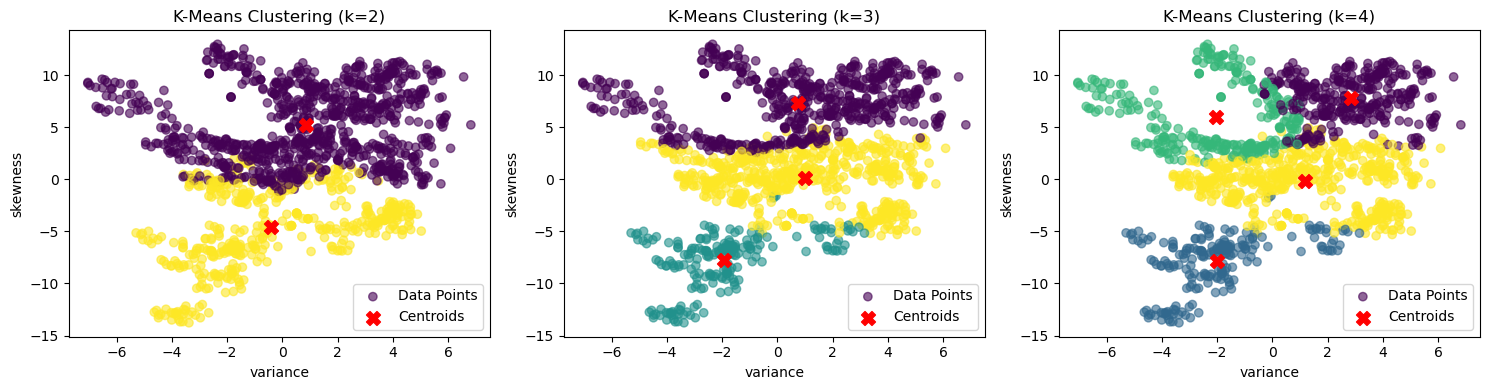

In [19]:
# 1(c) Clustering Visualization on Original Data

plt.figure(figsize=(15, 4))
x_feature = 'variance'
y_feature = 'skewness'

for i, k in enumerate(ks):
    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(data.drop('class', axis=1))
    centroids = kmeans.cluster_centers_
    
    plt.subplot(1, len(ks), i + 1)
    plt.scatter(data[x_feature], data[y_feature], c=cluster_labels, cmap='viridis', alpha=0.6, label='Data Points')
    plt.scatter(centroids[:, data.columns.get_loc(x_feature)], 
                centroids[:, data.columns.get_loc(y_feature)], 
                c='red', marker='X', s=100, label='Centroids')
    plt.xlabel(x_feature)
    plt.ylabel(y_feature)
    plt.title(f'K-Means Clustering (k={k})')
    plt.legend()

plt.tight_layout()
plt.show()


# 1(d) Dimensionality Reduction
**Objective:**  
Reduce the dimensionality of the dataset to 2 dimensions using Principal Component Analysis (PCA).

**Steps:**
1. Apply PCA on the original feature set.
2. Transform the data into 2 principal components.
3. Display the explained variance ratio to understand the variance captured by each component.

**Output:**  
PCA-reduced data and explained variance ratios.


In [20]:
# 1(d) Dimensionality Reduction using PCA

from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['class'] = y_true

print("Explained Variance Ratio:", pca.explained_variance_ratio_)


Explained Variance Ratio: [0.76132409 0.1419049 ]


# 1(e) Evaluation Metrics with PCA
**Objective:**  
Compute the evaluation metrics (ARI, Silhouette Score, and Percentage Accuracy) for K-Means clustering using the PCA-reduced data.

**Steps:**
1. Use the PCA-reduced data from part 1(d).
2. Apply K-Means clustering for k = 2, 3, 4.
3. Compute and plot ARI, Silhouette Score, and Percentage Accuracy.
4. Compare these metrics with those from the original data.

**Output:**  
Plots of ARI, Silhouette Score, and Percentage Accuracy vs. Number of Clusters (for PCA data).


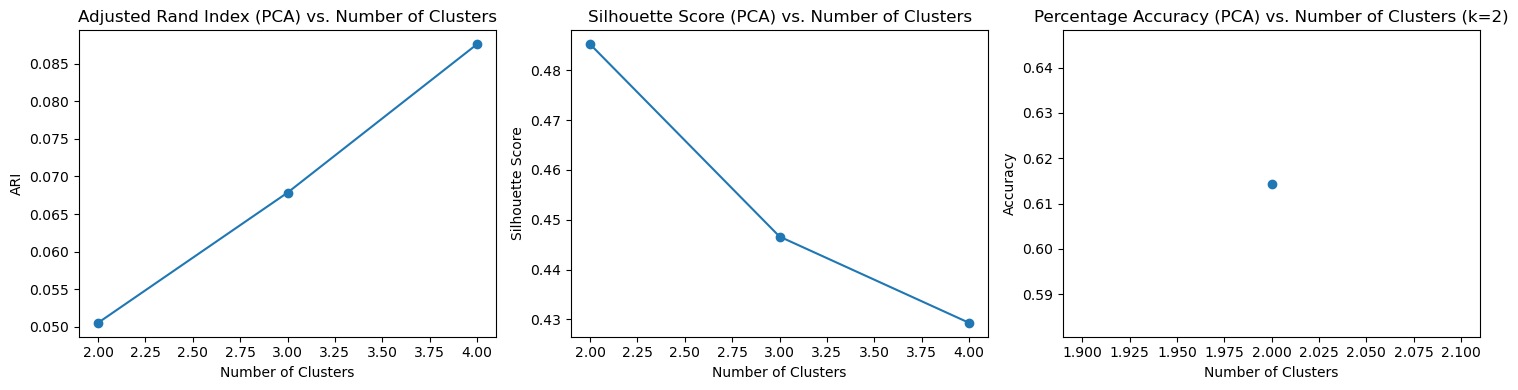

In [21]:
# 1(e) Evaluation Metrics with PCA-Reduced Data

ari_scores_pca = []
silhouette_scores_pca = []
accuracy_scores_pca = []

for k in ks:
    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(X_pca)
    
    ari = adjusted_rand_score(y_true, cluster_labels)
    ari_scores_pca.append(ari)
    
    sil_score = silhouette_score(X_pca, cluster_labels) if k > 1 else None
    silhouette_scores_pca.append(sil_score)
    
    if k == 2:
        acc = clustering_accuracy(y_true, cluster_labels)
    else:
        acc = None
    accuracy_scores_pca.append(acc)

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.plot(ks, ari_scores_pca, marker='o')
plt.title('Adjusted Rand Index (PCA) vs. Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('ARI')

plt.subplot(1, 3, 2)
plt.plot(ks, silhouette_scores_pca, marker='o')
plt.title('Silhouette Score (PCA) vs. Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')

plt.subplot(1, 3, 3)
plt.plot(ks, accuracy_scores_pca, marker='o')
plt.title('Percentage Accuracy (PCA) vs. Number of Clusters (k=2)')
plt.xlabel('Number of Clusters')
plt.ylabel('Accuracy')

plt.tight_layout()
plt.show()


# 1(f) Clustering with PCA Visualization
**Objective:**  
Visualize K-Means clustering results on the PCA-reduced data using a 2D scatter plot:
- **x-axis:** First Principal Component (PC1)
- **y-axis:** Second Principal Component (PC2)

**Steps:**
1. Apply K-Means clustering on the PCA-reduced data for k = 2, 3, 4.
2. Plot the clusters with different colors and mark the centroids.
3. Include ground truth labels for comparison.

**Output:**  
2D scatter plots of clusters (with centroids) on PCA data.


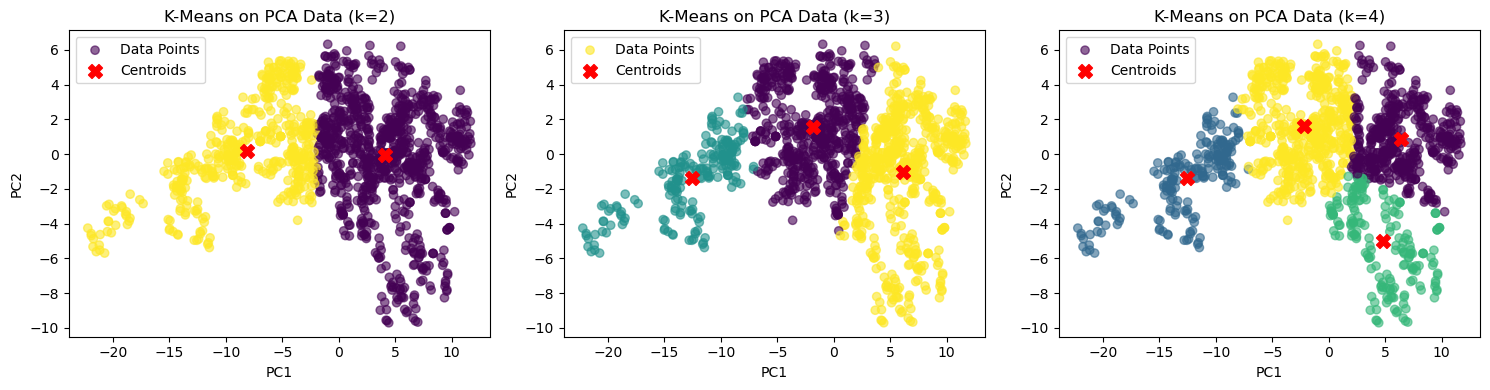

In [22]:
# 1(f) Clustering with PCA Visualization

plt.figure(figsize=(15, 4))
for i, k in enumerate(ks):
    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(X_pca)
    centroids = kmeans.cluster_centers_
    
    plt.subplot(1, len(ks), i + 1)
    plt.scatter(pca_df['PC1'], pca_df['PC2'], c=cluster_labels, cmap='viridis', alpha=0.6, label='Data Points')
    plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=100, label='Centroids')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title(f'K-Means on PCA Data (k={k})')
    plt.legend()

plt.tight_layout()
plt.show()


# 2(a) Dendrogram
**Objective:**  
Plot the dendrogram for the PCA-reduced data using Ward linkage to understand the hierarchical structure.

**Steps:**
1. Use the PCA-reduced data from part 1(d).
2. Compute the linkage matrix using Ward linkage.
3. Plot the dendrogram to help determine a suitable number of clusters.

**Output:**  
A dendrogram plot of the PCA-reduced data.


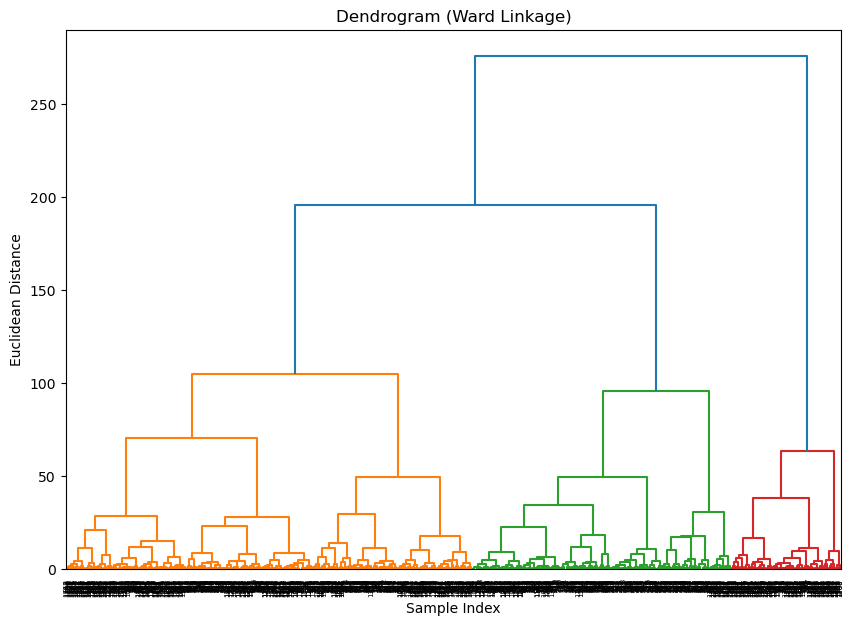

In [23]:
# 2(a) Dendrogram using Ward Linkage

import scipy.cluster.hierarchy as sch

linked = sch.linkage(X_pca, method='ward')

plt.figure(figsize=(10, 7))
dendro = sch.dendrogram(linked,
                        orientation='top',
                        distance_sort='descending',
                        show_leaf_counts=True)
plt.title('Dendrogram (Ward Linkage)')
plt.xlabel('Sample Index')
plt.ylabel('Euclidean Distance')
plt.show()


# 2(b) Clustering with Different Linkages
**Objective:**  
Apply Agglomerative Clustering on the PCA-reduced data using both Ward and Complete linkages, and visualize the clusters.

**Steps:**
1. Use the PCA-reduced data from part 1(d).
2. For each linkage method (Ward and Complete), perform clustering for k = 2, 3, and 4.
3. Plot the resulting clusters in 2D scatter plots (using PC1 and PC2).

**Output:**  
Scatter plots of clusters using different linkage methods.


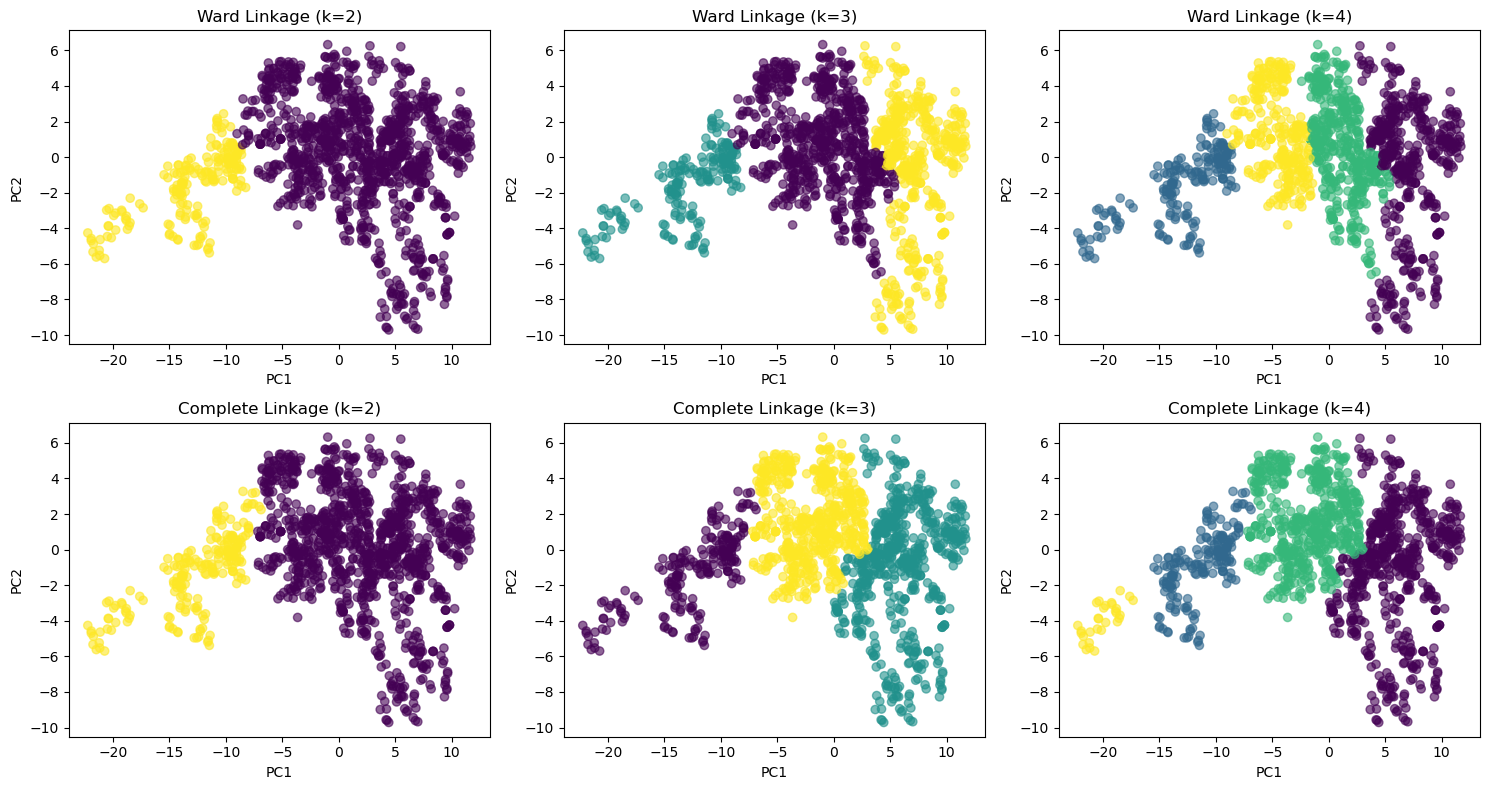

In [24]:
# 2(b) Clustering with Different Linkages

from sklearn.cluster import AgglomerativeClustering

linkage_methods = ['ward', 'complete']
ks_hier = [2, 3, 4]

plt.figure(figsize=(15, 8))
plot_idx = 1

for linkage in linkage_methods:
    for k in ks_hier:
        agglom = AgglomerativeClustering(n_clusters=k, linkage=linkage)
        cluster_labels = agglom.fit_predict(X_pca)
        
        plt.subplot(len(linkage_methods), len(ks_hier), plot_idx)
        plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis', alpha=0.6)
        plt.title(f'{linkage.capitalize()} Linkage (k={k})')
        plt.xlabel('PC1')
        plt.ylabel('PC2')
        plot_idx += 1

plt.tight_layout()
plt.show()
